In [2]:
import os, sys, importlib,pathlib
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))
import numpy as np
# my utils
from utils import axe_classification


In [8]:
df_predicted=pd.read_parquet("../external_data\embeddings_all\df_all_3emb_predicted.parquet")

# print(df_predicted.axe.value_counts(dropna=False),"\n")
print(df_predicted.final_axe.value_counts(dropna=False))
display(df_predicted.head())

final_axe
3          1324
1           811
2           269
1; 3        179
2; 3         74
4            46
1; 2; 3      18
1; 2         12
3; 4          1
Name: count, dtype: int64


,halId_s,uri_s,docType_s,title_s,subTitle_s,authFullName_s,authIdHal_s,labStructName_s,author_primarystructure_s,collName_s,...,fnege_year,axes_vec,axe1,axe2,axe3,axe4,emb_title_s,emb_keyword_s,emb_abstract_s,final_axe
14,hal-05354091,https://hal.science/hal-05354091v1,COMM,Les jeux vidéo FLOSS dans l’enseignement supér...,None,Philippe Lépinard,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Biblioth...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.07416533, -0.02507004, -0.056212127, -0.00...","[-0.038245093, -0.003676773, -0.055256307, -0....","[-0.0627323, -0.012661392, -0.04260565, -0.003...",3
20,hal-05321456,https://hal.u-pec.fr/hal-05321456v1,COUV,Unlocking Organizational Identity,A Consultant’s Playbook for Inclusion Advocacy,Éric Gautier Laurent; Catherine Voynnet-Fourboul,eric-gautier; catherine-voynnet-fourboul,Institut de Recherche en Gestion; Laboratoire ...,1004418_Institut de Recherche en Gestion;10964...,Sciences de l'Homme et de la Société; Universi...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.022757635, -0.0064444183, -0.042470817, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",3
33,hal-05302743,https://hal.science/hal-05302743v1,ART,Les Remote Carriers dans le combat collaborati...,None,Juliette Frédy; Cécile Godé; Philippe Lépinard,cecile-gode; philippe-lepinard,Centre d'Études et de Recherche en Gestion d'A...,420786_Université Paris-Est Créteil Val-de-Mar...,Sciences de l'Homme et de la Société; Universi...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.03761582, -0.006678919, -0.009912152, 0.01...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.074023664, 0.021094285, -0.00791859, 0.025...",3
40,hal-05295448,https://hal.science/hal-05295448v1,ART,Frugalité technologique et ludopédagogie en ma...,None,Philippe Lépinard; Prabpreet Singh,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion;17672...,Sciences de l'Homme et de la Société; Biblioth...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.081040576, 0.0018408684, -0.008541116, 0.0...","[-0.062362764, -0.028598065, -0.051758498, -0....","[-0.07686497, -0.0064801904, -0.03617584, -0.0...",3
42,hal-05288245,https://hal.science/hal-05288245v1,COUV,Perspectives pédagogiques ! Frugalité technolo...,None,Philippe Lépinard,philippe-lepinard,Institut de Recherche en Gestion,1004418_Institut de Recherche en Gestion,Sciences de l'Homme et de la Société; Biblioth...,...,2022,"[0, 0, 1, 0]",0,0,1,0,"[-0.09261081, -0.01070483, -0.017841782, 0.000...","[-0.054620333, -0.028326109, -0.0541471, 0.001...","[-0.07495657, 0.0016563429, -0.018859863, 0.01...",3


## try3:

In [26]:
"""
1️⃣ 把文章当作“节点”
2️⃣ 用“关系”来定义引力（而不是直接用坐标）
3️⃣ 用 force-directed layout 来“生成坐标”

"""


import networkx as nx

df=df_predicted.copy()


def parse_axes(x):
    if pd.isna(x):
        return []
    return [a.strip() for a in str(x).split(';')]
df=df_predicted.copy()
df['axe_list'] = df['final_axe'].apply(parse_axes)
all_axes = sorted({a for axes in df['axe_list'] for a in axes})


#Step 2：合并三种 embedding（稳健版本）
def combine_embeddings(row, w_title=1.0, w_kw=1.2, w_abs=1.5):
    vecs = []
    weights = []

    if isinstance(row['emb_title_s'], np.ndarray):
        vecs.append(row['emb_title_s'])
        weights.append(w_title)

    if isinstance(row['emb_keyword_s'], np.ndarray):
        vecs.append(row['emb_keyword_s'])
        weights.append(w_kw)

    if isinstance(row['emb_abstract_s'], np.ndarray):
        vecs.append(row['emb_abstract_s'])
        weights.append(w_abs)

    if not vecs:
        return None

    return np.average(vecs, axis=0, weights=weights)
df['combined_emb'] = df.apply(combine_embeddings, axis=1)


# print(df['combined_emb'].shape)  # shape = (n_articles, emb_dim)
# print(df['axe_list'])    # e.g. ['1'], ['1','3']

X = np.vstack(df['combined_emb'].dropna().values)
df_plot = df.loc[df['combined_emb'].notna()].copy()



def main_axe(axes):
    return axes[0] if axes else None

df_plot['main_axe'] = df_plot['axe_list'].apply(main_axe)



In [ ]:
#Step 1：节点 = 文章
G = nx.Graph()
for idx, row in df_plot.iterrows():
    G.add_node(
        idx,
        axe=row['axe_list'],
        emb=row['combined_emb']
    )

# Step 2：定义三种“力”
from sklearn.metrics.pairwise import cosine_similarity

#力 1：语义相似 → 吸引（弱）
X = np.vstack(df_plot['combined_emb'])
S = cosine_similarity(X)

K = 10  # 每个点只连最近的 K 个

for i in range(len(df_plot)):
    nn = np.argsort(S[i])[-(K+1):-1]
    for j in nn:
        G.add_edge(i, j, weight=0.3)



# 力 2：同 axe → 强吸引（关键）
for axe in all_axes:
    nodes = df_plot.index[df_plot['axe_list'].apply(lambda x: axe in x)]
    for i in nodes:
        for j in nodes:
            if i < j:
                G.add_edge(i, j, weight=1.0)
                
                
# 力 3：多 axe 文章 → 桥梁
# 多 axe 的文章自然成为桥，不需要特殊处理，它已经连着多个团。

In [24]:
pos = nx.spring_layout(
    G,
    weight='weight',
    iterations=100,
    seed=42
)


In [25]:
plt.figure(figsize=(10, 10))

for axe, g in df_plot.groupby('main_axe'):
    idxs = g.index
    plt.scatter(
        [pos[i][0] for i in idxs],
        [pos[i][1] for i in idxs],
        s=10,
        alpha=0.6,
        label=f"Axe {axe}"
    )

plt.legend()
plt.axis('off')
plt.show()


KeyError: 'main_axe'

<Figure size 1000x1000 with 0 Axes>

## try2

In [14]:
df=df_predicted.copy()

def parse_axes(x):
    if pd.isna(x):
        return []
    return [a.strip() for a in str(x).split(';')]
df=df_predicted.copy()
df['axe_list'] = df['final_axe'].apply(parse_axes)


#Step 2：合并三种 embedding（稳健版本）
def combine_embeddings(row, w_title=1.0, w_kw=1.2, w_abs=1.5):
    vecs = []
    weights = []

    if isinstance(row['emb_title_s'], np.ndarray):
        vecs.append(row['emb_title_s'])
        weights.append(w_title)

    if isinstance(row['emb_keyword_s'], np.ndarray):
        vecs.append(row['emb_keyword_s'])
        weights.append(w_kw)

    if isinstance(row['emb_abstract_s'], np.ndarray):
        vecs.append(row['emb_abstract_s'])
        weights.append(w_abs)

    if not vecs:
        return None

    return np.average(vecs, axis=0, weights=weights)
df['combined_emb'] = df.apply(combine_embeddings, axis=1)


# print(df['combined_emb'].shape)  # shape = (n_articles, emb_dim)
# print(df['axe_list'])    # e.g. ['1'], ['1','3']

X = np.vstack(df['combined_emb'].dropna().values)
df_plot = df.loc[df['combined_emb'].notna()].copy()


d:\miniconda3\envs\irg_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


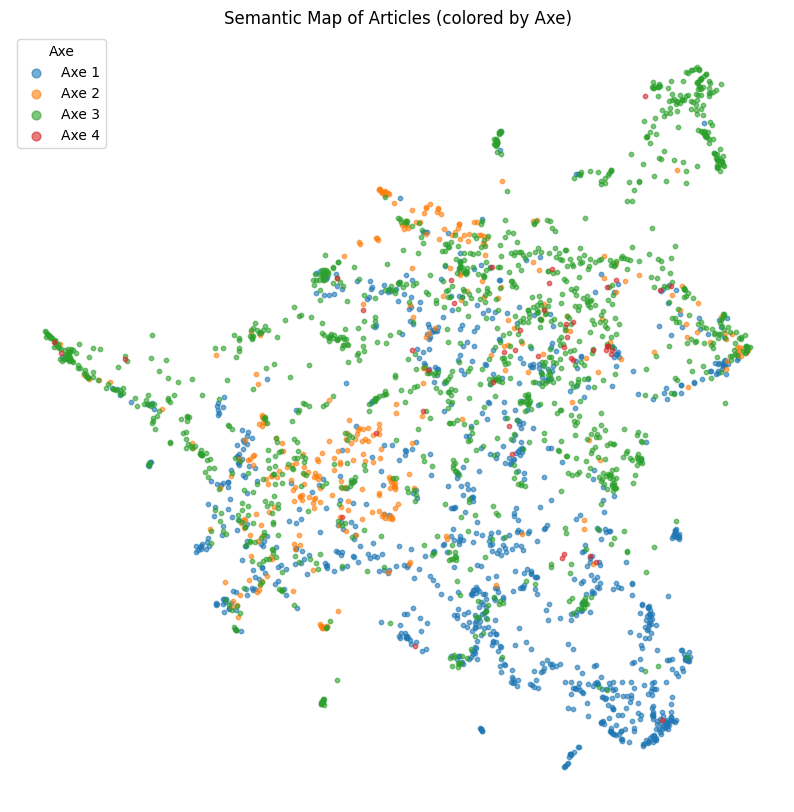

In [17]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_2d = reducer.fit_transform(X)
df_plot['x'] = X_2d[:, 0]
df_plot['y'] = X_2d[:, 1]




def main_axe(axes):
    return axes[0] if axes else None

df_plot['main_axe'] = df_plot['axe_list'].apply(main_axe)

plt.figure(figsize=(10, 10))

for axe, g in df_plot.groupby('main_axe'):
    plt.scatter(
        g['x'], g['y'],
        s=10,
        alpha=0.6,
        label=f"Axe {axe}"
    )

plt.legend(title="Axe", markerscale=2)
plt.title("Semantic Map of Articles (colored by Axe)")
plt.axis('off')
plt.show()


In [ ]:


for axe, emb in axe_embeddings.items():
    center = reducer.transform(emb.reshape(1, -1))
    plt.scatter(center[0,0], center[0,1],
                s=300, marker='X', edgecolor='black')
    plt.text(center[0,0], center[0,1], f"Axe {axe}",
             fontsize=12, weight='bold')




## TRY1

In [ ]:

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
def parse_axes(x):
    if pd.isna(x):
        return []
    return [a.strip() for a in str(x).split(';')]
df=df_predicted.copy()
df['axe_list'] = df['final_axe'].apply(parse_axes)


#Step 2：合并三种 embedding（稳健版本）
def combine_embeddings(row, w_title=1.0, w_kw=1.2, w_abs=1.5):
    vecs = []
    weights = []

    if isinstance(row['emb_title_s'], np.ndarray):
        vecs.append(row['emb_title_s'])
        weights.append(w_title)

    if isinstance(row['emb_keyword_s'], np.ndarray):
        vecs.append(row['emb_keyword_s'])
        weights.append(w_kw)

    if isinstance(row['emb_abstract_s'], np.ndarray):
        vecs.append(row['emb_abstract_s'])
        weights.append(w_abs)

    if not vecs:
        return None

    return np.average(vecs, axis=0, weights=weights)
df['combined_emb'] = df.apply(combine_embeddings, axis=1)



#Step 3：按 axe 聚合语义向量（关键）
axe_embeddings = {}
all_axes = sorted({a for axes in df['axe_list'] for a in axes})

for axe in all_axes:
    idx = df['axe_list'].apply(lambda x: axe in x)
    emb_list = df.loc[idx, 'combined_emb'].dropna().tolist()

    if emb_list:
        axe_embeddings[axe] = np.vstack(emb_list).mean(axis=0)


# Step 4：计算 axe–axe 语义相似度
axes = list(axe_embeddings.keys())
E = np.vstack([axe_embeddings[a] for a in axes])

S = cosine_similarity(E)
pd.DataFrame(S, index=axes, columns=axes)


,1,2,3,4
1,1.000000,0.970100,0.980873,0.950529
2,0.970100,1.000000,0.981196,0.950960
3,0.980873,0.981196,1.000000,0.966930
4,0.950529,0.950960,0.966930,1.000000


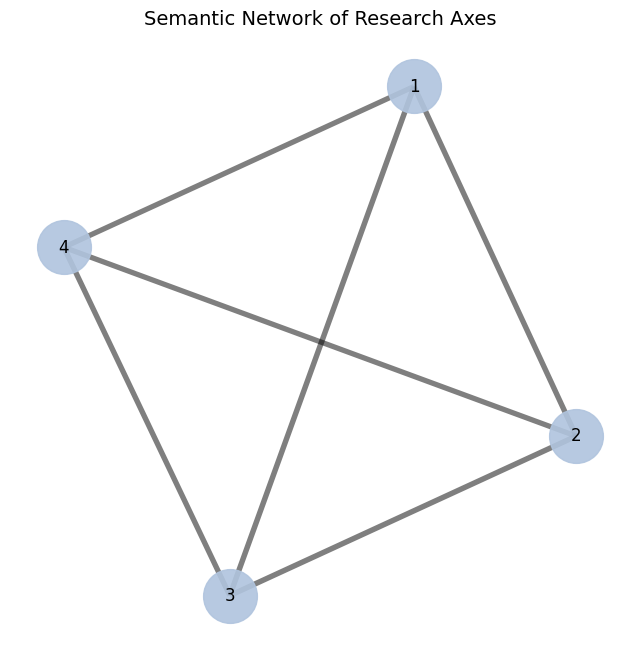

In [12]:
# Step 5：构建语义网络
G = nx.Graph()

for axe in axes:
    G.add_node(axe)

threshold = 0.3
for i, a1 in enumerate(axes):
    for j, a2 in enumerate(axes):
        if i < j and S[i, j] >= threshold:
            G.add_edge(a1, a2, weight=S[i, j])



# Step 6：力导向布局 + 可视化
pos = nx.spring_layout(G, weight='weight', seed=42)
plt.figure(figsize=(8, 8))

nx.draw_networkx_nodes(
    G, pos,
    node_size=1500,
    node_color='lightsteelblue',
    alpha=0.9
)

nx.draw_networkx_edges(
    G, pos,
    width=[G[u][v]['weight'] * 4 for u, v in G.edges()],
    alpha=0.5
)

nx.draw_networkx_labels(
    G, pos,
    font_size=12
)

plt.title("Semantic Network of Research Axes", fontsize=14)
plt.axis('off')
plt.show()


In [4]:
from utils.preprocess import explode_by_col
df_split=explode_by_col(df_predicted, col='final_axe')
print(len(df_predicted), len(df_split))
print(df_split.final_axe.value_counts(dropna=False))
print(df_split.language_s.value_counts(dropna=False))
# print(df_split.final_axe.dtype)
# display(df_split.head())

2734 3036
final_axe
3    1596
1    1020
2     373
4      47
Name: count, dtype: int64
language_s
fr    1834
en    1190
pt       5
es       4
ru       1
it       1
pl       1
Name: count, dtype: int64


## tfidf:

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
import json

path_stopwords='../external_data\stopwords_nltk.json'
with open(path_stopwords,'r', encoding='utf-8')as f:
    stopwords=json.load(f)

df_split["all_text"] = (
    df_split[["title_s", "keyword_s", "abstract_s"]]
    .fillna("")
    .agg(" ".join, axis=1)
    .str.strip()
)
display(df_split[['title_s','keyword_s','abstract_s','all_text']].head())

df_split_notna=df_split[df_split['all_text'].notna()]



print(len(df_split),len(df_split_notna))
print(df_split_notna.final_axe.value_counts(dropna=False))

vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words=stopwords,  # 或自定义
    ngram_range=(1,2)
)

X_tfidf = vectorizer.fit_transform(df_split_notna["all_text"])
print(X_tfidf.shape)

feature_names = np.array(vectorizer.get_feature_names_out())

,title_s,keyword_s,abstract_s,all_text
0,Entrepreneuriat de nécessité (versus opportuni...,NaN,Cet article étudie les déterminants de l’entre...,Entrepreneuriat de nécessité (versus opportuni...
0,Entrepreneuriat de nécessité (versus opportuni...,NaN,Cet article étudie les déterminants de l’entre...,Entrepreneuriat de nécessité (versus opportuni...
1,Responsible entrepreneurship: From motivations...,Burkina Faso; GEM; Modèle de la valeur; Entrep...,Cet article étudie les déterminants des modèle...,Responsible entrepreneurship: From motivations...
1,Responsible entrepreneurship: From motivations...,Burkina Faso; GEM; Modèle de la valeur; Entrep...,Cet article étudie les déterminants des modèle...,Responsible entrepreneurship: From motivations...
2,Agencer des safe spaces en marketing des servi...,Marketing des services; Sécurité; Transformati...,NaN,Agencer des safe spaces en marketing des servi...


3039 3039
final_axe
3      1546
1       994
2       405
4        85
nan       9
Name: count, dtype: int64
(3039, 3000)


In [62]:
# def top_terms_for_axe(axe_label, top_k=15):
#     idx = df_split_abstract["final_axe"] == axe_label
#     tfidf_mean = X_tfidf[idx].mean(axis=0)
#     top_idx = np.argsort(tfidf_mean.A1)[::-1][:top_k]
#     return feature_names[top_idx]

def top_terms_for_axe(axe_label, top_k=15):
    idx = (df_split_notna["final_axe"] == axe_label).values
    tfidf_mean = X_tfidf[idx].mean(axis=0)
    top_idx = np.argsort(tfidf_mean.A1)[::-1][:top_k]
    return feature_names[top_idx]

dict_axes={
    "1": "Performances et responsabilités",
    "2": "Société de services et services à la société",
    "3": "Innovations, transformations et résistances organisationnelles et sociétales",
    "4": "Ouvrages pédagogiques"
}


for axe in ["1","2","3","4"]:
    kw=top_terms_for_axe(axe_label=axe, top_k=15)
    print(f"AXE {dict_axes.get(axe,None)}: \n{kw}\n")
    


AXE Performances et responsabilités: 
['management' 'performance' 'entreprises' 'corporate' 'gestion' 'social'
 'capital' 'rse' 'entreprise' 'financial' 'france' 'market' 'sociale'
 'french' 'firms']

AXE Société de services et services à la société: 
['service' 'marketing' 'client' 'services' 'customer' 'management'
 'relation' 'participation' 'travail' 'clients' 'recherche' 'santé'
 'research' 'confiance' 'place']

AXE Innovations, transformations et résistances organisationnelles et sociétales: 
['management' 'innovation' 'recherche' 'gestion' 'luxe' 'ludopédagogie'
 'travail' 'marketing' 'research' 'changement' 'pratiques' 'france'
 'parfumerie' 'organisations' 'organizational']

AXE Ouvrages pédagogiques: 
['recherche' 'management' 'cas' 'gestion' 'ouvrage' 'marketing'
 'ressources' 'collecte' 'finance' 'cet ouvrage' 'grh' 'formation'
 'chapitre' 'action' 'cet']



In [64]:
from itertools import combinations
from collections import Counter
nodes = top_terms_for_axe("1", top_k=30)

edges = Counter()
for text in df_split_notna[df_split_notna["final_axe"]=="1"]["all_text"]:
    words = set(text.split()) & set(nodes)
    for pair in combinations(words, 2):
        edges[pair] += 1
edges

Counter({('recherche', 'article'): 23,
         ('recherche', 'sociale'): 6,
         ('article', 'sociale'): 12,
         ('développement', 'durable'): 31,
         ('développement', 'article'): 16,
         ('développement', 'corporate'): 4,
         ('développement', 'sociale'): 15,
         ('développement', 'performance'): 5,
         ('durable', 'article'): 9,
         ('durable', 'corporate'): 3,
         ('durable', 'sociale'): 11,
         ('durable', 'performance'): 4,
         ('article', 'corporate'): 6,
         ('article', 'performance'): 14,
         ('corporate', 'sociale'): 2,
         ('corporate', 'performance'): 19,
         ('sociale', 'performance'): 8,
         ('social', 'développement'): 10,
         ('social', 'durable'): 8,
         ('social', 'sociale'): 27,
         ('social', 'recherche'): 15,
         ('développement', 'recherche'): 23,
         ('durable', 'recherche'): 10,
         ('sociale', 'recherche'): 8,
         ('sociale', 'innovation'): 1,
    

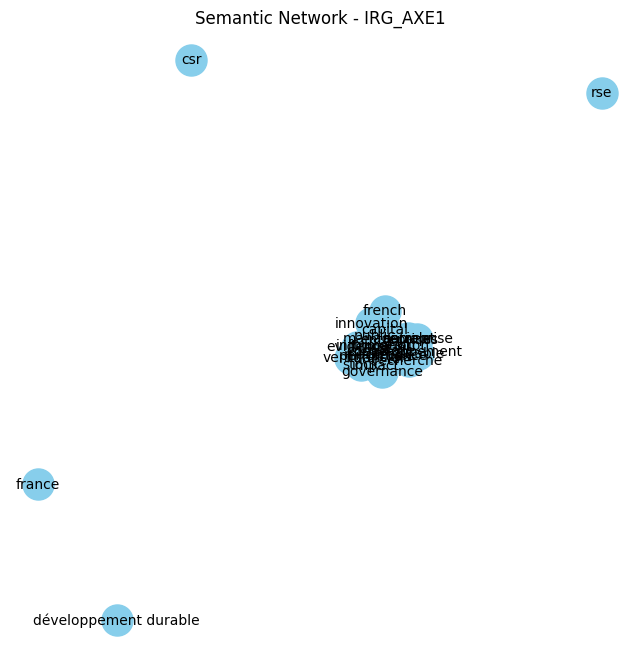

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_nodes_from(nodes)
for (w1, w2), weight in edges.items():
    G.add_edge(w1, w2, weight=weight)

plt.figure(figsize=(8,8))
pos = nx.spring_layout(G, k=0.3)
nx.draw_networkx_nodes(G, pos, node_size=500, node_color="skyblue")
nx.draw_networkx_edges(G, pos, width=[d['weight']*0.2 for (u,v,d) in G.edges(data=True)])
nx.draw_networkx_labels(G, pos, font_size=10)
plt.title("Réseau sémantique")
plt.axis("off")
plt.show()


## clustering within axe:

In [ ]:
from sklearn.cluster import KMeans

def cluster_within_axe(axe_label, k=2):
    idx = df["final_axe"] == axe_label
    X = np.stack(df.loc[idx, "emb_abstract_s"])
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    return labels
